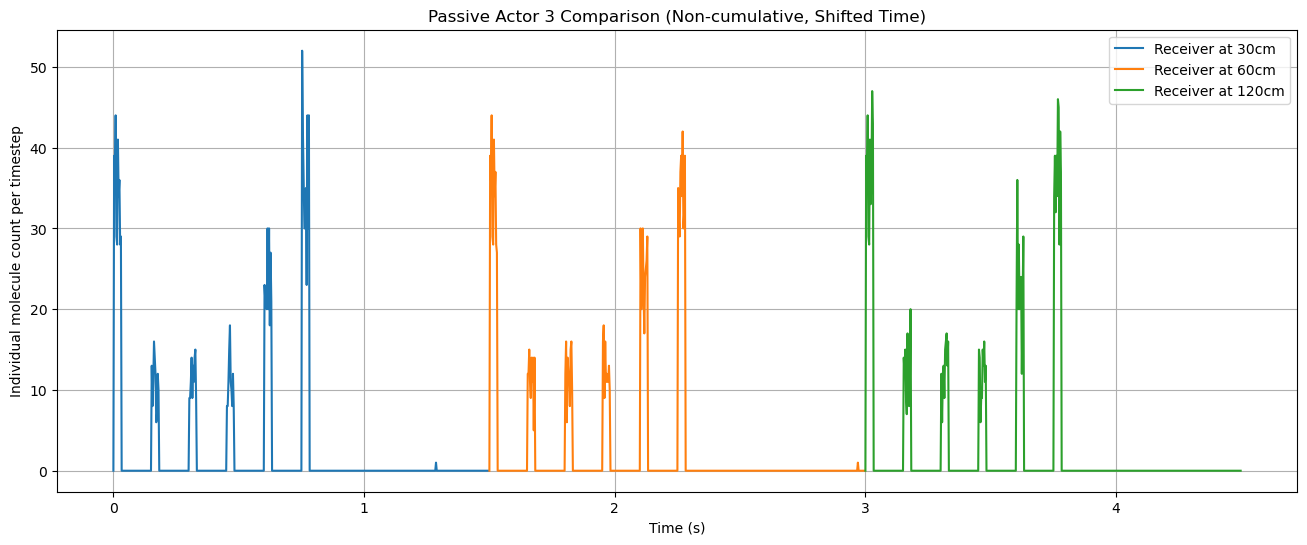

In [115]:
import re
import numpy as np
import matplotlib.pyplot as plt

def extract_individual_counts(filename, actor_id=3):
    """
    Extract per-timestep (non-cumulative) molecule counts for a given PassiveActor.
    """
    with open(filename, 'r') as f:
        text = f.read()

    # Regex to capture "PassiveActor <id>: ... Count: <numbers>"
    pattern = rf"PassiveActor\s+{actor_id}:.*?Count:\s*((?:\d+\s+)+)"
    matches = re.findall(pattern, text, flags=re.DOTALL)

    if not matches:
        print(f"Warning: No counts found for PassiveActor {actor_id} in {filename}")
        return np.array([])

    # Combine all matches into a single cumulative array
    cumulative_counts = []
    for match in matches:
        nums = [int(x) for x in match.strip().split()]
        cumulative_counts.extend(nums)

    cumulative_counts = np.array(cumulative_counts)

    # Convert cumulative → individual counts
    individual_counts = np.diff(cumulative_counts, prepend=0)
    return individual_counts

# -----------------------------
# File paths
# -----------------------------
file1 = "accord_sample_communication_chemical_distance_30_SEED1.txt"
file2 = "accord_sample_communication_chemical_distance_60_SEED1.txt"
file3 = "accord_sample_communication_chemical_distance_120_SEED1.txt"

# -----------------------------
# Extract individual counts
# -----------------------------
counts1 = extract_individual_counts(file1, actor_id=3)
counts2 = extract_individual_counts(file2, actor_id=3)
counts3 = extract_individual_counts(file3, actor_id=3)

# -----------------------------
# Check counts
# -----------------------------
if counts1.size == 0 or counts2.size == 0 or counts3.size == 0:
    raise ValueError("No counts were extracted. Check the actor ID and file formatting!")

# -----------------------------
# Create time axes
# -----------------------------
dt = 0.003  # simulation timestep
time1 = np.arange(len(counts1)) * dt
time2 = np.arange(len(counts2)) * dt
time3 = np.arange(len(counts3)) * dt

# -----------------------------
# Apply time offsets
# -----------------------------
offset_2 = time1[-1] + dt
offset_3 = offset_2 + time2[-1] + dt

time2_shifted = time2 + offset_2
time3_shifted = time3 + offset_3

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(16,6))
plt.plot(time1, counts1, label='Receiver at 30cm')
plt.plot(time2_shifted, counts2, label='Receiver at 60cm')
plt.plot(time3_shifted, counts3, label='Receiver at 120cm')
plt.xlabel("Time (s)")
plt.ylabel("Individual molecule count per timestep")
plt.title("Passive Actor 3 Comparison (Non-cumulative, Shifted Time)")
plt.legend()
plt.grid(True)
plt.show()


In [75]:
import re
import numpy as np
import matplotlib.pyplot as plt

def extract_individual_counts(filename, actor_id=3):
    """
    Extract per-timestep (non-cumulative) molecule counts for a given PassiveActor.
    """
    with open(filename, 'r') as f:
        text = f.read()

    # Regex to capture "PassiveActor <id>: ... Count: <numbers>"
    pattern = rf"PassiveActor\s+{actor_id}:.*?Count:\s*((?:\d+\s+)+)"
    matches = re.findall(pattern, text, flags=re.DOTALL)

    if not matches:
        print(f"Warning: No counts found for PassiveActor {actor_id} in {filename}")
        return np.array([])

    # Combine all matches into a single cumulative array
    cumulative_counts = []
    for match in matches:
        nums = [int(x) for x in match.strip().split()]
        cumulative_counts.extend(nums)

    cumulative_counts = np.array(cumulative_counts)

    # Convert cumulative → individual counts
    individual_counts = np.diff(cumulative_counts, prepend=0)
    return individual_counts

# -----------------------------
# File paths
# -----------------------------
file1 = "distance_30_SEED1.txt"
file2 = "distance_30_SEED1.txt"
file3 = "accord_sample_communication_chemical_distance_120_SEED1.txt"

# -----------------------------
# Extract individual counts
# -----------------------------
counts1 = extract_individual_counts(file1, actor_id=3)
counts2 = extract_individual_counts(file2, actor_id=3)
counts3 = extract_individual_counts(file3, actor_id=3)

# -----------------------------
# Check counts
# -----------------------------
if counts1.size == 0 or counts2.size == 0 or counts3.size == 0:
    raise ValueError("No counts were extracted. Check the actor ID and file formatting!")

# -----------------------------
# Create time axes
# -----------------------------
dt = 0.003  # simulation timestep
time1 = np.arange(len(counts1)) * dt
time2 = np.arange(len(counts2)) * dt
time3 = np.arange(len(counts3)) * dt

# -----------------------------
# Apply time offsets
# -----------------------------
offset_2 = time1[-1] + dt
offset_3 = offset_2 + time2[-1] + dt

time2_shifted = time2 + offset_2
time3_shifted = time3 + offset_3

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(16,6))
plt.plot(time1, counts1, label='Receiver at 30cm')
plt.plot(time2_shifted, counts2, label='Receiver at 60cm')
plt.plot(time3_shifted, counts3, label='Receiver at 120cm')
plt.xlabel("Time (s)")
plt.ylabel("Individual molecule count per timestep")
plt.title("Passive Actor 3 Comparison (Non-cumulative, Shifted Time)")
plt.legend()
plt.grid(True)
plt.show()


ValueError: No counts were extracted. Check the actor ID and file formatting!

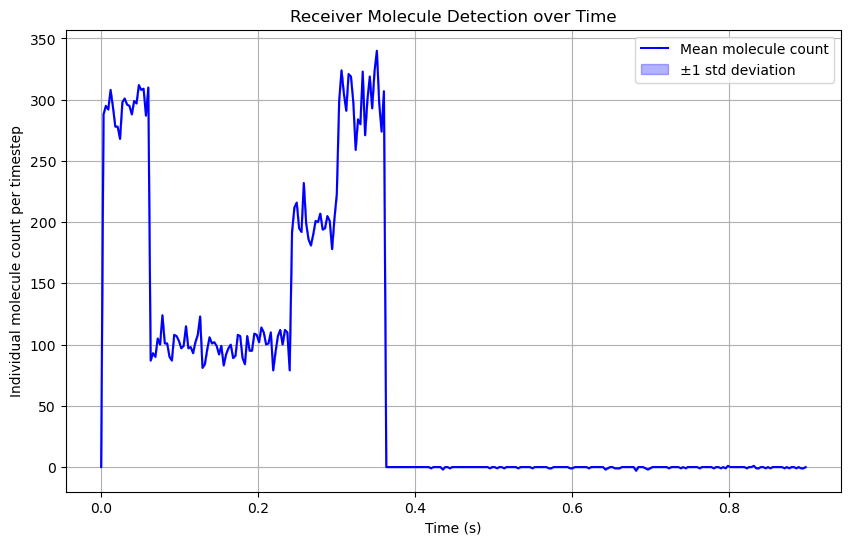

In [85]:
import re
import numpy as np
import matplotlib.pyplot as plt

def extract_realization_counts(filename, actor_id=2):
    """
    Extract individual molecule counts for all realizations for a given PassiveActor.
    Returns a 2D numpy array: rows = realizations, columns = timesteps.
    """
    with open(filename, 'r') as f:
        text = f.read()

    # Split text into realizations
    realizations = text.split("Realization")
    
    all_counts = []

    for r in realizations[1:]:  # skip the first split part
        # Regex to capture "PassiveActor <id>: ... Count: <numbers>"
        pattern = rf"PassiveActor\s+{actor_id}:.*?Count:\s*((?:\d+\s+)+)"
        match = re.search(pattern, r, flags=re.DOTALL)
        if match:
            nums = [int(x) for x in match.group(1).strip().split()]
            # Convert cumulative → individual counts
            counts = np.diff(nums, prepend=0)
            all_counts.append(counts)

    return np.array(all_counts)  # shape: (num_realizations, num_timesteps)

# -----------------------------
# File path
# -----------------------------
filename = "distance_60_SEED1.txt"

# -----------------------------
# Extract counts for PassiveActor 2 (receiver)
# -----------------------------
counts_array = extract_realization_counts(filename, actor_id=2)

if counts_array.size == 0:
    raise ValueError("No counts extracted! Check actor ID and file format.")

# -----------------------------
# Compute statistics
# -----------------------------
mean_counts = counts_array.mean(axis=0)
std_counts = counts_array.std(axis=0)

# -----------------------------
# Create time axis
# -----------------------------
dt = 0.003  # adjust to your simulation timestep
time = np.arange(counts_array.shape[1]) * dt

# -----------------------------
# Plot mean ± standard deviation
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(time, mean_counts, label='Mean molecule count', color='blue')
plt.fill_between(time, mean_counts - std_counts, mean_counts + std_counts,
                 color='blue', alpha=0.3, label='±1 std deviation')
plt.xlabel("Time (s)")
plt.ylabel("Individual molecule count per timestep")
plt.title("Receiver Molecule Detection over Time")
plt.legend()
plt.grid(True)
plt.show()


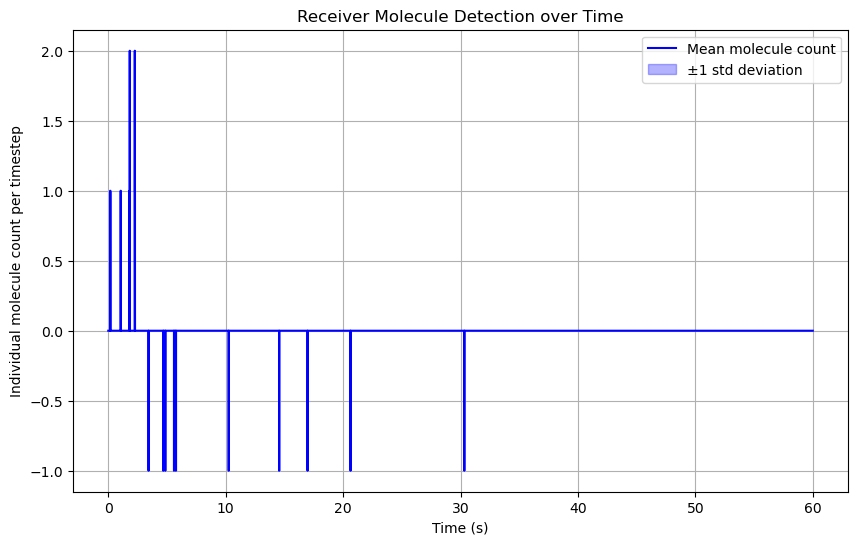

In [120]:
import re
import numpy as np
import matplotlib.pyplot as plt

def extract_realization_counts(filename, actor_id=2):
    """
    Extract individual molecule counts for all realizations for a given PassiveActor.
    Returns a 2D numpy array: rows = realizations, columns = timesteps.
    """
    with open(filename, 'r') as f:
        text = f.read()

    # Split text into realizations
    realizations = text.split("Realization")
    
    all_counts = []

    for r in realizations[1:]:  # skip the first split part
        # Regex to capture "PassiveActor <id>: ... Count: <numbers>"
        pattern = rf"PassiveActor\s+{actor_id}:.*?Count:\s*((?:\d+\s+)+)"
        match = re.search(pattern, r, flags=re.DOTALL)
        if match:
            nums = [int(x) for x in match.group(1).strip().split()]
            # Convert cumulative → individual counts
            counts = np.diff(nums, prepend=0)
            all_counts.append(counts)

    return np.array(all_counts)  # shape: (num_realizations, num_timesteps)

# -----------------------------
# File path
# -----------------------------
filename = "encoding_technique_1_SEED1.txt"

# -----------------------------
# Extract counts for PassiveActor 2 (receiver)
# -----------------------------
counts_array = extract_realization_counts(filename, actor_id=2)

if counts_array.size == 0:
    raise ValueError("No counts extracted! Check actor ID and file format.")

# -----------------------------
# Compute statistics
# -----------------------------
mean_counts = counts_array.mean(axis=0)
std_counts = counts_array.std(axis=0)

# -----------------------------
# Create time axis
# -----------------------------
dt = 0.003  # adjust to your simulation timestep
time = np.arange(counts_array.shape[1]) * dt

# -----------------------------
# Plot mean ± standard deviation
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(time, mean_counts, label='Mean molecule count', color='blue')
plt.fill_between(time, mean_counts - std_counts, mean_counts + std_counts,
                 color='blue', alpha=0.3, label='±1 std deviation')
plt.xlabel("Time (s)")
plt.ylabel("Individual molecule count per timestep")
plt.title("Receiver Molecule Detection over Time")
plt.legend()
plt.grid(True)
plt.show()


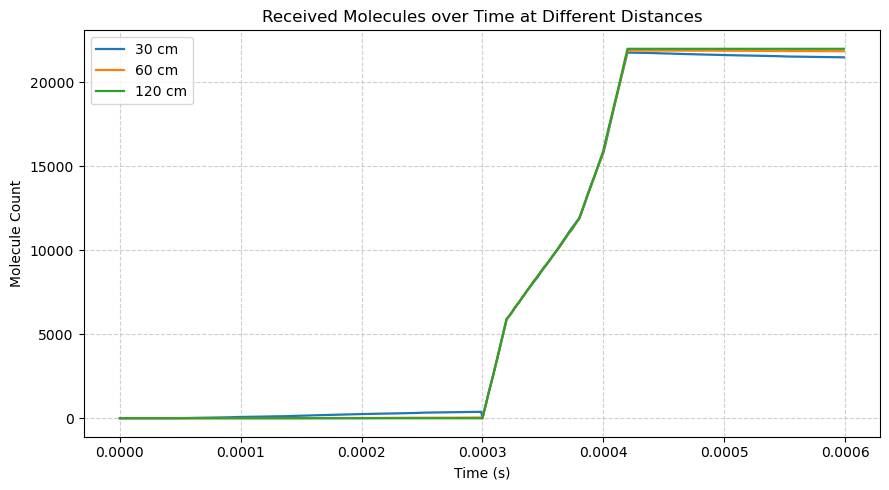

In [113]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load data files for each distance ---
# Replace with your actual filenames
files = {
    "30 cm": "distance_30_SEED1.txt",
    "60 cm": "distance_60_SEED1.txt",
    "120 cm": "distance_120_SEED1.txt"
}

# --- Helper function to read molecule count data ---
def extract_counts(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    # Extract numeric values after 'Count:'
    count_data = []
    record = False
    for line in lines:
        if "Count:" in line:
            record = True
            continue
        if record:
            if line.strip() == "":
                break
            count_data.extend([int(x) for x in line.split() if x.isdigit()])
    return np.array(count_data)

# --- Plotting ---
plt.figure(figsize=(9, 5))

for label, path in files.items():
    counts = extract_counts(path)
    timesteps = np.arange(len(counts)) * 1e-6  # adjust if your timestep differs
    plt.plot(timesteps, counts, label=label, linewidth=1.6)

plt.title("Received Molecules over Time at Different Distances")
plt.xlabel("Time (s)")
plt.ylabel("Molecule Count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


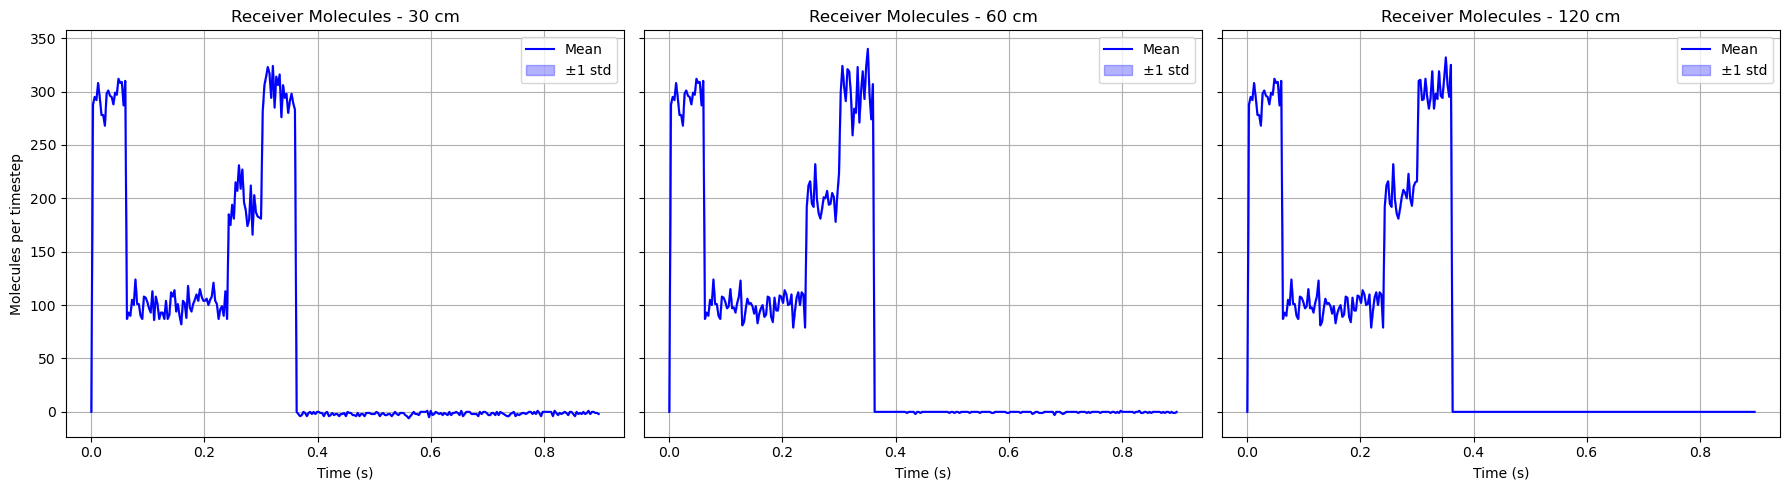

In [111]:
import re
import numpy as np
import matplotlib.pyplot as plt

def extract_realization_counts(filename, actor_id=2):
    """
    Extract individual molecule counts for all realizations for a given PassiveActor.
    Returns a 2D numpy array: rows = realizations, columns = timesteps.
    """
    with open(filename, 'r') as f:
        text = f.read()

    # Split text into realizations
    realizations = text.split("Realization")
    
    all_counts = []

    for r in realizations[1:]:  # skip the first split part
        # Regex to capture "PassiveActor <id>: ... Count: <numbers>"
        pattern = rf"PassiveActor\s+{actor_id}:.*?Count:\s*((?:\d+\s+)+)"
        match = re.search(pattern, r, flags=re.DOTALL)
        if match:
            nums = [int(x) for x in match.group(1).strip().split()]
            # Convert cumulative → individual counts
            counts = np.diff(nums, prepend=0)
            all_counts.append(counts)

    return np.array(all_counts)  # shape: (num_realizations, num_timesteps)

# -----------------------------
# File paths
# -----------------------------
files = {
    "30 cm": "distance_30_SEED1.txt",
    "60 cm": "distance_60_SEED1.txt",
    "120 cm": "distance_120_SEED1.txt"
}

# Simulation timestep
dt = 0.003  # adjust if needed

# -----------------------------
# Plot all three graphs side-by-side
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (label, file) in zip(axes, files.items()):
    counts_array = extract_realization_counts(file, actor_id=2)
    
    if counts_array.size == 0:
        raise ValueError(f"No counts extracted from {file}!")

    mean_counts = counts_array.mean(axis=0)
    std_counts = counts_array.std(axis=0)
    time = np.arange(counts_array.shape[1]) * dt

    ax.plot(time, mean_counts, color='blue', label='Mean')
    ax.fill_between(time, mean_counts - std_counts, mean_counts + std_counts,
                    color='blue', alpha=0.3, label='±1 std')
    ax.set_title(f"Receiver Molecules - {label}")
    ax.set_xlabel("Time (s)")
    ax.grid(True)
    if ax == axes[0]:
        ax.set_ylabel("Molecules per timestep")
    ax.legend()

plt.tight_layout()
plt.show()
